# Actividad 3. Limpieza y preprocesamiento de datos

**Estadística Aplicada · Maestría en Inteligencia Artificial**

## Objetivos

En este notebook documentamos paso a paso el proceso de limpieza y preparación de datos para un dataset de precios de vivienda. La idea es dejar un rastro claro de cada decisión tomada: qué se hizo, por qué se hizo de esa forma y qué efecto tuvo sobre los datos, de manera que el trabajo se pueda revisar o repetir sin ambigüedades.

- Entender a fondo la estructura, el contenido y la calidad del dataset antes de modificarlo.
- Aplicar las técnicas de limpieza y transformación que pide la actividad, justificando cada una.
- Dejar los datos listos para un análisis multivariante y, eventualmente, para entrenar un modelo.

## El dataset: House Prices (Ames, Iowa)

Para esta actividad se usa el dataset **House Prices - Advanced Regression Techniques**, publicado en Kaggle y construido originalmente por Dean De Cock como una alternativa más rica y actualizada al clásico dataset de Boston Housing. Reúne las ventas de viviendas residenciales registradas en la ciudad de Ames, Iowa, entre 2006 y 2010, con un nivel de detalle poco común: no solo precios y metros cuadrados, sino también características de acabados, calidad de materiales, antigüedad, tipo de garaje, exposición del sótano, entre muchas otras.

Se trabaja específicamente con el archivo `train.csv`, que contiene **1,460 viviendas** descritas por **81 variables**. De esas 81, `Id` es simplemente un identificador de fila (no aporta información analítica) y `SalePrice` es la variable objetivo: el precio final de venta en dólares, que es justo lo que se buscaría predecir en un ejercicio de modelado. Sin esas dos columnas quedan **79 predictores**, de los cuales 36 son numéricos (superficies, años, conteos de habitaciones, etc.) y 43 son categóricos (tipo de zona, estilo de techo, calidad de acabados, condición del garaje, y así sucesivamente).

Se eligió este dataset porque combina dos retos muy representativos de un flujo real de limpieza de datos: por un lado, una buena cantidad de valores faltantes que no siempre significan "dato perdido" (a veces significan "la casa no tiene esa característica", como un sótano o una alberca); por otro, una mezcla amplia de tipos de variable que obliga a decidir, caso por caso, si conviene imputar, codificar, escalar o transformar. Kaggle incluye además un diccionario de datos (`data_description.txt`) que describe el significado de cada variable y sus posibles categorías, el cual se usa más adelante para construir un diccionario de trabajo propio.

## Cómo está organizado el notebook

El notebook sigue el orden de los incisos de la actividad, sección por sección. Una decisión importante de diseño: el archivo fuente (`data_raw`) nunca se modifica directamente; cada transformación genera una copia nueva del DataFrame (`df_deduplicated`, `df_imputed`, `df_outlier_handled`, etc.), de modo que siempre es posible volver atrás y comparar el estado de los datos antes y después de cualquier paso.

In [1]:
from importlib.util import find_spec
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SEED = 2026
np.random.seed(SEED)
pd.set_option("display.max_columns", 100)

current_dir = Path.cwd().resolve()
if current_dir.name == "notebooks":
    PROJECT_ROOT = current_dir.parent
elif (current_dir / "archive").is_dir():
    PROJECT_ROOT = current_dir
elif (current_dir / "Tarea03").is_dir():
    PROJECT_ROOT = current_dir / "Tarea03"
else:
    PROJECT_ROOT = current_dir / "primerCuatrimestre" / "estadisticaAplicada" / "Tarea03"

ARCHIVE_DIR = PROJECT_ROOT / "archive"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR = OUTPUT_DIR / "tables"
for directory in (FIGURES_DIR, TABLES_DIR):
    directory.mkdir(parents=True, exist_ok=True)

SEABORN_AVAILABLE = find_spec("seaborn") is not None
SKLEARN_AVAILABLE = find_spec("sklearn") is not None
if SEABORN_AVAILABLE:
    import seaborn as sns

    sns.set_theme(style="whitegrid", palette="deep")
else:
    plt.style.use("seaborn-v0_8-whitegrid")
PLOT_COLORS = {"blue": "#2e75b6", "light_blue": "#8cbce4", "dark_blue": "#4c78a8"}

## 2. Carga del dataset

Se arranca cargando `train.csv`, que es el único archivo que sirve para este ejercicio: contiene la variable objetivo `SalePrice`. El archivo `test.csv` que también viene en el paquete de Kaggle se deja fuera a propósito, ya que no trae el precio de venta y por lo tanto no aporta nada para el diagnóstico ni para la limpieza que se realiza aquí.

In [2]:
TRAIN_PATH = ARCHIVE_DIR / "train.csv"
data_raw = pd.read_csv(TRAIN_PATH)

print(f"Dimensiones: {data_raw.shape[0]:,} registros x {data_raw.shape[1]} variables")
display(data_raw.head())
print("Información general:")
data_raw.info()

Dimensiones: 1,460 registros x 81 variables


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


Información general:
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18

## 3. Diagnóstico inicial estructural y de calidad

Antes de limpiar nada, conviene tomarse un momento para "conocer" el dataset: ¿cuántos tipos de dato hay?, ¿dónde están los huecos?, ¿hay filas repetidas?, ¿cómo se ven las estadísticas descriptivas básicas? Todo esto se calcula sobre `data_raw` sin alterarlo, y las tablas junto con la figura resultante se guardan en `outputs/` para poder consultarlas después sin tener que re-ejecutar el notebook completo.

Variables numéricas: 38 | categóricas: 43
Registros: 1,460 | duplicados: 0 | faltantes: 7,829


,faltantes,faltantes_pct,tipo
PoolQC,1453,99.520548,str
MiscFeature,1406,96.301370,str
Alley,1369,93.767123,str
Fence,1179,80.753425,str
MasVnrType,872,59.726027,str
FireplaceQu,690,47.260274,str
LotFrontage,259,17.739726,float64
GarageYrBlt,81,5.547945,float64
GarageCond,81,5.547945,str
GarageType,81,5.547945,str


,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


Estadística descriptiva completa guardada para 37 variables numéricas.


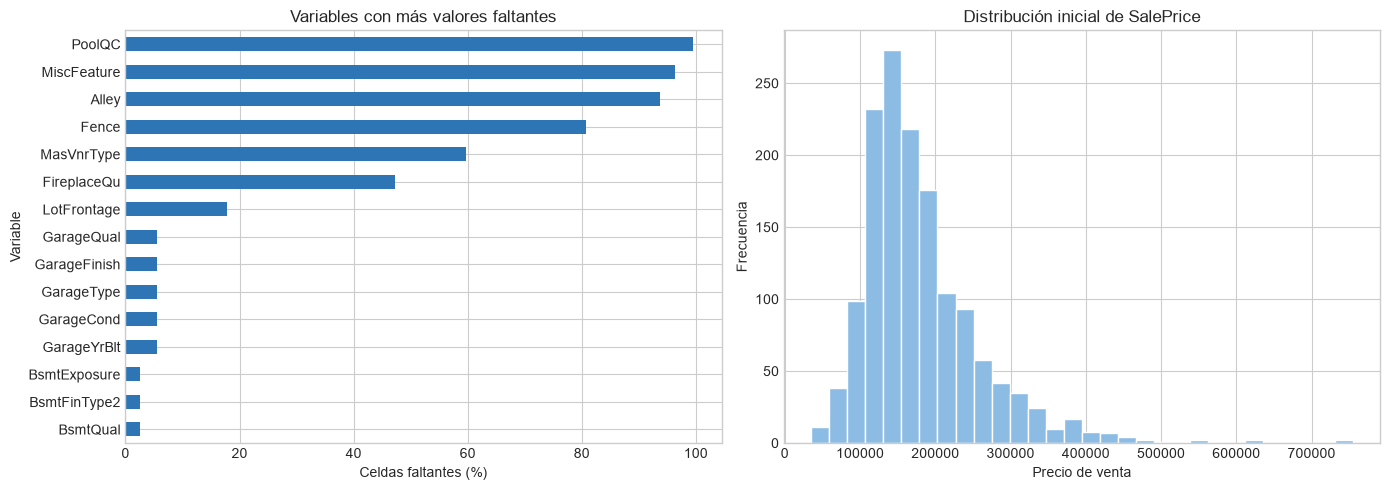

In [ ]:
NUMERIC_COLUMNS = data_raw.select_dtypes(include="number").columns.tolist()
CATEGORICAL_COLUMNS = data_raw.select_dtypes(exclude="number").columns.tolist()

missing_summary = pd.DataFrame(
    {
        "faltantes": data_raw.isna().sum(),
        "faltantes_pct": data_raw.isna().mean().mul(100),
        "tipo": data_raw.dtypes.astype(str),
    }
).sort_values("faltantes", ascending=False)
missing_summary = missing_summary.loc[missing_summary["faltantes"] > 0]
base_numeric_stats = data_raw[NUMERIC_COLUMNS].describe().T
base_row_count, base_column_count = data_raw.shape
base_duplicate_count = int(data_raw.duplicated().sum())
base_missing_count = int(data_raw.isna().sum().sum())

initial_profile = pd.DataFrame(
    {
        "tipo": data_raw.dtypes.astype(str),
        "categorias_o_valores_unicos": data_raw.nunique(dropna=True),
        "faltantes": data_raw.isna().sum(),
        "faltantes_pct": data_raw.isna().mean().mul(100),
    }
)
print(f"Variables numéricas: {len(NUMERIC_COLUMNS)} | categóricas: {len(CATEGORICAL_COLUMNS)}")
print(f"Registros: {base_row_count:,} | duplicados: {base_duplicate_count} | faltantes: {base_missing_count:,}")
display(missing_summary.head(15))
display(base_numeric_stats)
initial_profile.to_csv(TABLES_DIR / "diagnostico_inicial.csv", index=True)

# Estadística descriptiva completa de los 36 predictores numéricos y SalePrice, para el anexo del informe; Id se excluye por ser solo un identificador.
ANEXO_NUMERIC_COLUMNS = [column for column in NUMERIC_COLUMNS if column != "Id"]
full_quantitative_stats = pd.DataFrame(
    {
        "n": data_raw[ANEXO_NUMERIC_COLUMNS].count(),
        "media": data_raw[ANEXO_NUMERIC_COLUMNS].mean(),
        "mediana": data_raw[ANEXO_NUMERIC_COLUMNS].median(),
        "moda": data_raw[ANEXO_NUMERIC_COLUMNS].mode().iloc[0],
        "minimo": data_raw[ANEXO_NUMERIC_COLUMNS].min(),
        "Q1": data_raw[ANEXO_NUMERIC_COLUMNS].quantile(0.25),
        "Q3": data_raw[ANEXO_NUMERIC_COLUMNS].quantile(0.75),
        "maximo": data_raw[ANEXO_NUMERIC_COLUMNS].max(),
    }
)
full_quantitative_stats.to_csv(TABLES_DIR / "estadistica_descriptiva_completa.csv", index=True)
print(f"Estadística descriptiva completa guardada para {len(full_quantitative_stats)} variables numéricas.")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
missing_summary.head(15).sort_values("faltantes_pct").plot.barh(
    y="faltantes_pct", ax=axes[0], legend=False, color=PLOT_COLORS["blue"]
)
axes[0].set_title("Variables con más valores faltantes")
axes[0].set_xlabel("Celdas faltantes (%)")
axes[0].set_ylabel("Variable")
data_raw["SalePrice"].plot.hist(
    bins=30, ax=axes[1], color=PLOT_COLORS["light_blue"], edgecolor="white"
)
axes[1].set_title("Distribución inicial de SalePrice")
axes[1].set_xlabel("Precio de venta")
axes[1].set_ylabel("Frecuencia")
fig.tight_layout()
initial_diagnostic_figure = FIGURES_DIR / "diagnostico_inicial.png"
fig.savefig(initial_diagnostic_figure, dpi=160, bbox_inches="tight")
plt.show()

## 4. Diccionario de variables y tipología

Con 81 columnas es fácil perderse, así que se construye un diccionario propio que junta tres cosas: el tipo de dato que pandas detectó, el tipo analítico (numérica o categórica) y la definición oficial que aparece en la documentación de Kaggle. `Id` se marca como identificador y `SalePrice` como variable objetivo; cualquier variable sin una definición clara en la documentación queda señalada para revisarla con más cuidado antes de usarla.

In [ ]:
DESCRIPTION_PATH = ARCHIVE_DIR / "data_description.txt"
description_text = DESCRIPTION_PATH.read_text(encoding="utf-8")
variable_descriptions = {}
for line in description_text.splitlines():
    if not line or line[0].isspace() or ":" not in line:
        continue
    variable_name, description = line.split(":", maxsplit=1)
    if variable_name in data_raw.columns:
        variable_descriptions[variable_name] = description.strip()

variable_roles = {
    column: "identificador" if column == "Id" else "objetivo" if column == "SalePrice" else "predictor"
    for column in data_raw.columns
}
variable_dictionary = pd.DataFrame(
    {
        "variable": data_raw.columns,
        "dtype_observado": [str(data_raw[column].dtype) for column in data_raw.columns],
        "tipo_analitico": ["numérica" if column in NUMERIC_COLUMNS else "categórica" for column in data_raw.columns],
        "rol": [variable_roles[column] for column in data_raw.columns],
        "descripcion_documentada": [
            variable_descriptions.get(
                column,
                "Sin descripción explícita en la documentación suministrada; verificar antes de interpretar.",
            )
            for column in data_raw.columns
        ],
    }
)

print(f"Variables con descripción: {len(variable_descriptions)}/{len(data_raw.columns)}")
display(variable_dictionary)
variable_dictionary.to_csv(TABLES_DIR / "diccionario_variables.csv", index=False)

Variables con descripción: 79/81


,variable,dtype_observado,tipo_analitico,rol,descripcion_documentada
0,Id,int64,numérica,identificador,Sin descripción explícita en la documentación ...
1,MSSubClass,int64,numérica,predictor,Identifies the type of dwelling involved in th...
2,MSZoning,str,categórica,predictor,Identifies the general zoning classification o...
3,LotFrontage,float64,numérica,predictor,Linear feet of street connected to property
4,LotArea,int64,numérica,predictor,Lot size in square feet
...,...,...,...,...,...
76,MoSold,int64,numérica,predictor,Month Sold (MM)
77,YrSold,int64,numérica,predictor,Year Sold (YYYY)
78,SaleType,str,categórica,predictor,Type of sale
79,SaleCondition,str,categórica,predictor,Condition of sale


## 5. Eliminación de duplicados

Aquí solo se buscan duplicados "exactos", es decir, filas completas que sean idénticas en todas sus columnas. Se compara el número de registros antes y después de la operación para confirmar si realmente había algo que limpiar o si el dataset ya venía libre de este problema.

In [ ]:
df_deduplicated = data_raw.drop_duplicates().copy()
deduplication_summary = pd.DataFrame(
    {
        "registros": [len(data_raw), len(df_deduplicated)],
        "duplicados_exactos": [int(data_raw.duplicated().sum()), int(df_deduplicated.duplicated().sum())],
    },
    index=["Antes", "Después"],
)
display(deduplication_summary)
print(f"Filas retiradas: {len(data_raw) - len(df_deduplicated)}")

,registros,duplicados_exactos
Antes,1460,0
Después,1460,0


Filas retiradas: 0


## 6. Imputación de valores faltantes

Siguiendo lo que pide la actividad, se imputan las columnas numéricas con la mediana y las categóricas con la etiqueta `Sin_dato`. Para cada variable afectada se mide cuántos valores cambiaron y se confirma que el total de faltantes llegue a cero. Vale la pena mencionar algo que se retoma en la discusión final: varios de estos "faltantes" no son errores de captura, sino que indican que la casa simplemente no tiene esa característica (por ejemplo, un valor ausente en la calidad del sótano probablemente significa que no hay sótano).

In [ ]:
df_imputed = df_deduplicated.copy(deep=True)
imputation_records = []

for column in df_imputed.columns:
    missing_before = int(df_imputed[column].isna().sum())
    if missing_before == 0:
        continue
    if column in NUMERIC_COLUMNS:
        fill_value = df_imputed[column].median()
        method = "mediana"
    else:
        fill_value = "Sin_dato"
        method = "Sin_dato"
    df_imputed[column] = df_imputed[column].fillna(fill_value)
    imputation_records.append(
        {
            "variable": column,
            "tipo": "numérica" if column in NUMERIC_COLUMNS else "categórica",
            "metodo": method,
            "faltantes_antes": missing_before,
            "faltantes_despues": int(df_imputed[column].isna().sum()),
        }
    )

imputation_impact = pd.DataFrame(imputation_records)
missing_after_imputation = int(df_imputed.isna().sum().sum())
display(imputation_impact)
print(f"Celdas faltantes antes: {base_missing_count:,}")
print(f"Celdas faltantes después: {missing_after_imputation:,}")
imputation_impact.to_csv(TABLES_DIR / "impacto_imputacion.csv", index=False)

,variable,tipo,metodo,faltantes_antes,faltantes_despues
0,LotFrontage,numérica,mediana,259,0
1,Alley,categórica,Sin_dato,1369,0
2,MasVnrType,categórica,Sin_dato,872,0
3,MasVnrArea,numérica,mediana,8,0
4,BsmtQual,categórica,Sin_dato,37,0
5,BsmtCond,categórica,Sin_dato,37,0
6,BsmtExposure,categórica,Sin_dato,38,0
7,BsmtFinType1,categórica,Sin_dato,37,0
8,BsmtFinType2,categórica,Sin_dato,38,0
9,Electrical,categórica,Sin_dato,1,0


Celdas faltantes antes: 7,829
Celdas faltantes después: 0


## 7. Detección y tratamiento de valores atípicos con IQR

Se usa el método del rango intercuartílico (IQR) para identificar valores atípicos en cinco variables clave: `SalePrice`, `LotArea`, `GrLivArea`, `TotalBsmtSF` y `GarageArea`. No se elimina ningún registro completo; en su lugar, se aplica un recorte (clipping) solo en el extremo superior de los predictores, dejando `SalePrice` intacto porque es la variable que se quiere explicar, no corregir. Los ceros en `TotalBsmtSF` tampoco se tocan, ya que representan viviendas que de verdad no tienen sótano, no errores de medición.

,variable,limite_inferior,limite_superior,atipicos_inferiores,atipicos_superiores,atipicos_antes,valores_clippeados,atipicos_despues,tratamiento
0,SalePrice,3937.500,340037.500,0,61,61,0,61,sin clipping (objetivo)
1,LotArea,1481.500,17673.500,2,67,69,67,2,clipping superior
2,GrLivArea,158.625,2747.625,0,31,31,31,0,clipping superior
3,TotalBsmtSF,42.000,2052.000,37,24,61,24,37,clipping superior
4,GarageArea,-27.750,938.250,0,21,21,21,0,clipping superior


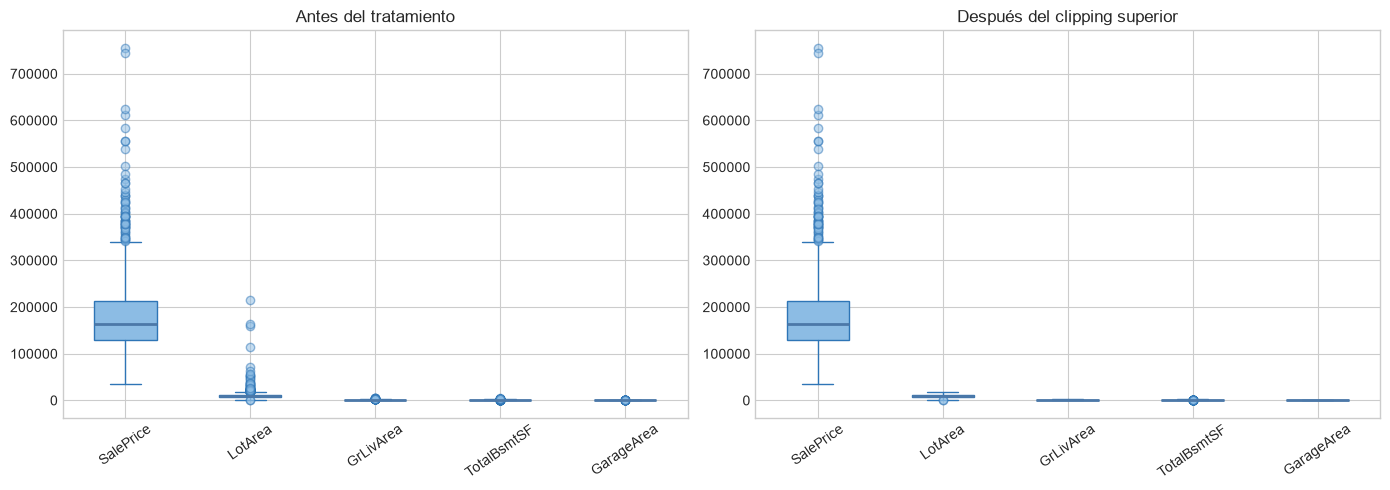

Filas conservadas: 1,460


In [ ]:
OUTLIER_COLUMNS = ["SalePrice", "LotArea", "GrLivArea", "TotalBsmtSF", "GarageArea"]
CLIP_COLUMNS = ["LotArea", "GrLivArea", "TotalBsmtSF", "GarageArea"]
df_outlier_handled = df_imputed.copy(deep=True)
outlier_records = []
iqr_bounds = {}

for column in OUTLIER_COLUMNS:
    q1 = df_imputed[column].quantile(0.25)
    q3 = df_imputed[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    iqr_bounds[column] = (lower_bound, upper_bound)
    lower_outliers = int((df_imputed[column] < lower_bound).sum())
    upper_outliers = int((df_imputed[column] > upper_bound).sum())
    if column in CLIP_COLUMNS:
        df_outlier_handled[column] = df_outlier_handled[column].clip(upper=upper_bound)
    outliers_after = int(
        ((df_outlier_handled[column] < lower_bound) | (df_outlier_handled[column] > upper_bound)).sum()
    )
    outlier_records.append(
        {
            "variable": column,
            "limite_inferior": lower_bound,
            "limite_superior": upper_bound,
            "atipicos_inferiores": lower_outliers,
            "atipicos_superiores": upper_outliers,
            "atipicos_antes": lower_outliers + upper_outliers,
            "valores_clippeados": int(
                (df_imputed[column] != df_outlier_handled[column]).sum()
            ),
            "atipicos_despues": outliers_after,
            "tratamiento": "sin clipping (objetivo)" if column == "SalePrice" else "clipping superior",
        }
    )

outlier_summary = pd.DataFrame(outlier_records)
display(outlier_summary)
outlier_summary.to_csv(TABLES_DIR / "diagnostico_outliers_iqr.csv", index=False)

boxplot_style = {
    "patch_artist": True,
    "boxprops": {"facecolor": PLOT_COLORS["light_blue"], "edgecolor": PLOT_COLORS["blue"]},
    "medianprops": {"color": PLOT_COLORS["dark_blue"], "linewidth": 2},
    "whiskerprops": {"color": PLOT_COLORS["blue"]},
    "capprops": {"color": PLOT_COLORS["blue"]},
    "flierprops": {
        "markerfacecolor": PLOT_COLORS["light_blue"],
        "markeredgecolor": PLOT_COLORS["blue"],
        "alpha": 0.5,
    },
}
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].boxplot(
    [df_imputed[column] for column in OUTLIER_COLUMNS],
    tick_labels=OUTLIER_COLUMNS,
    **boxplot_style,
)
axes[0].set_title("Antes del tratamiento")
axes[0].tick_params(axis="x", rotation=35)
axes[1].boxplot(
    [df_outlier_handled[column] for column in OUTLIER_COLUMNS],
    tick_labels=OUTLIER_COLUMNS,
    **boxplot_style,
)
axes[1].set_title("Después del clipping superior")
axes[1].tick_params(axis="x", rotation=35)
fig.tight_layout()
outlier_figure = FIGURES_DIR / "comparacion_outliers_iqr.png"
fig.savefig(outlier_figure, dpi=160, bbox_inches="tight")
plt.show()
print(f"Filas conservadas: {len(df_outlier_handled):,}")

## 8. Normalización con MinMaxScaler

Se lleva `SalePrice` y cuatro predictores numéricos a una escala común entre 0 y 1, comparando los rangos antes y después para verificar que la transformación se aplicó correctamente. `SalePrice` se incluye únicamente con fines ilustrativos: no formará parte de las variables usadas para entrenar un modelo, para evitar que el objetivo se "filtre" entre los predictores. Si scikit-learn no está disponible en el entorno, el notebook recurre a la fórmula Min-Max implementada manualmente con NumPy, y lo deja indicado para que quede constancia de esa limitación.

,min_antes,max_antes,min_despues,max_despues,implementacion
SalePrice,34900.0,755000.000,0.0,1.0,Fórmula Min-Max equivalente implementada con N...
LotArea,1300.0,17673.500,0.0,1.0,Fórmula Min-Max equivalente implementada con N...
GrLivArea,334.0,2747.625,0.0,1.0,Fórmula Min-Max equivalente implementada con N...
TotalBsmtSF,0.0,2052.000,0.0,1.0,Fórmula Min-Max equivalente implementada con N...
GarageArea,0.0,938.250,0.0,1.0,Fórmula Min-Max equivalente implementada con N...


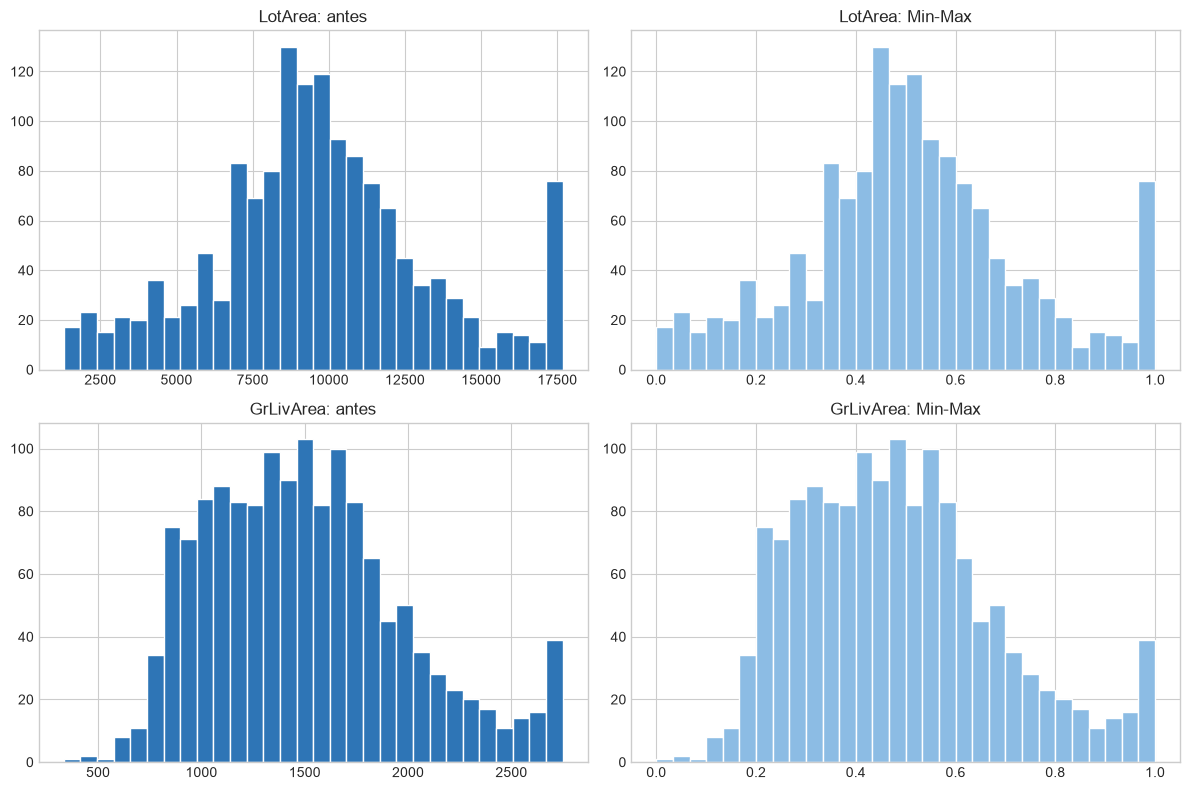

In [ ]:
NORMALIZATION_COLUMNS = ["SalePrice", "LotArea", "GrLivArea", "TotalBsmtSF", "GarageArea"]
normalization_source = df_outlier_handled[NORMALIZATION_COLUMNS].astype(float)

if SKLEARN_AVAILABLE:
    from sklearn.preprocessing import MinMaxScaler

    minmax_scaler = MinMaxScaler()
    minmax_values = minmax_scaler.fit_transform(normalization_source)
    scaling_backend = "scikit-learn MinMaxScaler"
else:
    source_min = normalization_source.min()
    source_range = normalization_source.max() - source_min
    safe_range = source_range.mask(source_range == 0, 1)
    minmax_values = (normalization_source - source_min) / safe_range
    scaling_backend = "Fórmula Min-Max equivalente implementada con NumPy/Pandas"

minmax_scaled = pd.DataFrame(
    minmax_values, columns=NORMALIZATION_COLUMNS, index=normalization_source.index
)
normalization_summary = pd.DataFrame(
    {
        "min_antes": normalization_source.min(),
        "max_antes": normalization_source.max(),
        "min_despues": minmax_scaled.min(),
        "max_despues": minmax_scaled.max(),
    }
)
normalization_summary["implementacion"] = scaling_backend
display(normalization_summary)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for row, column in enumerate(["LotArea", "GrLivArea"]):
    axes[row, 0].hist(
        normalization_source[column], bins=30, color=PLOT_COLORS["blue"], edgecolor="white"
    )
    axes[row, 0].set_title(f"{column}: antes")
    axes[row, 1].hist(
        minmax_scaled[column], bins=30, color=PLOT_COLORS["light_blue"], edgecolor="white"
    )
    axes[row, 1].set_title(f"{column}: Min-Max")
fig.tight_layout()
minmax_figure = FIGURES_DIR / "comparacion_normalizacion_minmax.png"
fig.savefig(minmax_figure, dpi=160, bbox_inches="tight")
plt.show()

## 9. Estandarización con StandardScaler

Se repite el ejercicio anterior, pero ahora centrando y escalando las variables según su media y desviación estándar (es decir, llevándolas a puntuaciones z). El notebook indica explícitamente si se usó `StandardScaler` de scikit-learn o la fórmula equivalente calculada a mano (con desviación poblacional, `ddof=0`). Igual que antes, `SalePrice` solo se transforma para fines comparativos, no como insumo para un modelo.

,media_antes,desviacion_antes,media_despues,desviacion_despues,implementacion
SalePrice,180921.195890,79415.291886,1.362685e-16,1.0,Fórmula Z equivalente implementada con NumPy/P...
LotArea,9647.260616,3593.417900,5.596741e-17,1.0,Fórmula Z equivalente implementada con NumPy/P...
GrLivArea,1503.735873,481.210759,3.771717e-17,1.0,Fórmula Z equivalente implementada con NumPy/P...
TotalBsmtSF,1049.190411,400.544634,9.976799e-17,1.0,Fórmula Z equivalente implementada con NumPy/P...
GarageArea,470.670719,207.034790,-7.543433e-17,1.0,Fórmula Z equivalente implementada con NumPy/P...


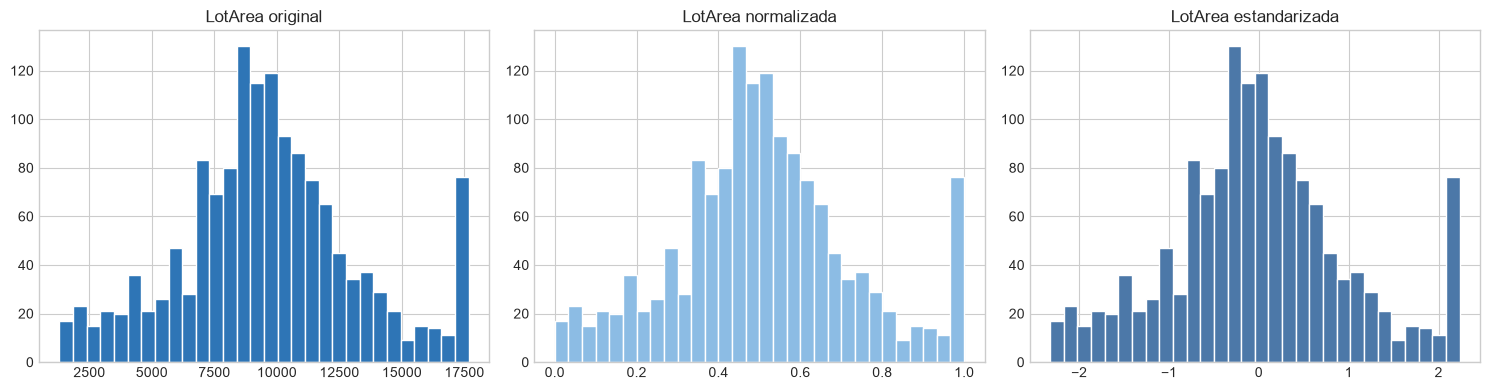

In [ ]:
if SKLEARN_AVAILABLE:
    from sklearn.preprocessing import StandardScaler

    standard_scaler = StandardScaler()
    standard_values = standard_scaler.fit_transform(normalization_source)
    standardization_backend = "scikit-learn StandardScaler"
else:
    source_mean = normalization_source.mean()
    source_std = normalization_source.std(ddof=0).mask(lambda values: values == 0, 1)
    standard_values = (normalization_source - source_mean) / source_std
    standardization_backend = "Fórmula Z equivalente implementada con NumPy/Pandas"

standardized = pd.DataFrame(
    standard_values, columns=NORMALIZATION_COLUMNS, index=normalization_source.index
)
standardization_summary = pd.DataFrame(
    {
        "media_antes": normalization_source.mean(),
        "desviacion_antes": normalization_source.std(ddof=0),
        "media_despues": standardized.mean(),
        "desviacion_despues": standardized.std(ddof=0),
    }
)
standardization_summary["implementacion"] = standardization_backend
display(standardization_summary)
scaling_comparison = normalization_summary.add_prefix("minmax_").join(
    standardization_summary.add_prefix("z_")
)
scaling_comparison.to_csv(TABLES_DIR / "comparacion_escalado.csv")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(normalization_source["LotArea"], bins=30, color=PLOT_COLORS["blue"], edgecolor="white")
axes[0].set_title("LotArea original")
axes[1].hist(minmax_scaled["LotArea"], bins=30, color=PLOT_COLORS["light_blue"], edgecolor="white")
axes[1].set_title("LotArea normalizada")
axes[2].hist(standardized["LotArea"], bins=30, color=PLOT_COLORS["dark_blue"], edgecolor="white")
axes[2].set_title("LotArea estandarizada")
fig.tight_layout()
standardization_figure = FIGURES_DIR / "comparacion_escalados.png"
fig.savefig(standardization_figure, dpi=160, bbox_inches="tight")
plt.show()

## 10. Conversión de tipos (`MSSubClass`, `MoSold`, `YrSold`)

Tres columnas numéricas merecen un tipo de dato distinto al que traen por defecto. `MSSubClass` en realidad es un código que identifica una clase de vivienda, no una cantidad, así que se convierte a categoría. `MoSold` (el mes de venta) cabe perfectamente en un entero pequeño (`int8`), y `YrSold` (el año) en uno de 16 bits (`int16`). Se compara el tipo y la memoria utilizada antes y después para mostrar que el cambio no es solo semántico, también ahorra espacio.

In [ ]:
type_columns = ["MSSubClass", "MoSold", "YrSold"]
df_typed = df_outlier_handled.copy(deep=True)
types_before = {column: str(df_typed[column].dtype) for column in type_columns}
memory_before = int(df_typed[type_columns].memory_usage(deep=True).sum())

df_typed["MSSubClass"] = df_typed["MSSubClass"].astype("category")
df_typed["MoSold"] = df_typed["MoSold"].astype("int8")
df_typed["YrSold"] = df_typed["YrSold"].astype("int16")

type_summary = pd.DataFrame(
    {
        "tipo_antes": types_before,
        "tipo_despues": {column: str(df_typed[column].dtype) for column in type_columns},
        "valores_unicos": {column: df_typed[column].nunique() for column in type_columns},
    }
)
memory_after = int(df_typed[type_columns].memory_usage(deep=True).sum())
type_summary.loc["Memoria (bytes)"] = [memory_before, memory_after, np.nan]
display(type_summary)
type_summary.to_csv(TABLES_DIR / "conversion_tipos.csv")
print(f"Memoria de columnas seleccionadas antes/después: {memory_before:,} / {memory_after:,} bytes")

,tipo_antes,tipo_despues,valores_unicos
MSSubClass,int64,category,15.0
MoSold,int64,int8,12.0
YrSold,int64,int16,5.0
Memoria (bytes),35172.0,6092.0,NaN


Memoria de columnas seleccionadas antes/después: 35,172 / 6,092 bytes


## 11. Codificación de variables categóricas

No todas las variables categóricas se codifican igual. Las que tienen un orden claro y documentado —calidad, condición, exposición y tipo de acabado del sótano, por ejemplo— reciben una codificación ordinal, respetando ese orden. El resto, que no tiene jerarquía natural, se transforma con One-Hot Encoding. Como en pasos anteriores, `Id` y `SalePrice` quedan fuera de la matriz de predictores: uno porque no aporta información, y el otro porque es justo lo que se quiere predecir.

In [ ]:
QUALITY_ORDER = {"Sin_dato": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5}
ORDINAL_MAPS = {
    column: QUALITY_ORDER
    for column in [
        "ExterQual", "ExterCond", "BsmtQual", "BsmtCond", "HeatingQC",
        "KitchenQual", "FireplaceQu", "GarageQual", "GarageCond", "PoolQC",
    ]
}
ORDINAL_MAPS.update(
    {
        "BsmtExposure": {"Sin_dato": 0, "No": 1, "Mn": 2, "Av": 3, "Gd": 4},
        "GarageFinish": {"Sin_dato": 0, "Unf": 1, "RFn": 2, "Fin": 3},
        "BsmtFinType1": {"Sin_dato": 0, "Unf": 1, "LwQ": 2, "Rec": 3, "BLQ": 4, "ALQ": 5, "GLQ": 6},
        "BsmtFinType2": {"Sin_dato": 0, "Unf": 1, "LwQ": 2, "Rec": 3, "BLQ": 4, "ALQ": 5, "GLQ": 6},
    }
)

def encode_predictors(frame):
    predictor_frame = frame.drop(columns=["Id", "SalePrice"]).copy()
    for column, mapping in ORDINAL_MAPS.items():
        predictor_frame[column] = predictor_frame[column].map(mapping).astype("int8")
    nominal_columns = predictor_frame.select_dtypes(exclude="number").columns
    encoded = pd.get_dummies(predictor_frame, columns=nominal_columns, dtype=np.int8)
    return encoded, list(ORDINAL_MAPS), list(nominal_columns)

X_encoded, LABEL_ENCODED_COLUMNS, ONE_HOT_INPUT_COLUMNS = encode_predictors(df_typed)
encoding_summary = pd.DataFrame(
    [
        {
            "metodo": "Codificación ordinal",
            "numero_variables": len(LABEL_ENCODED_COLUMNS),
            "columnas_generadas": len(LABEL_ENCODED_COLUMNS),
        },
        {
            "metodo": "One-Hot",
            "numero_variables": len(ONE_HOT_INPUT_COLUMNS),
            "columnas_generadas": len(X_encoded.columns) - (len(df_typed.columns) - 2),
        },
    ]
)
display(encoding_summary)
print(f"Predictores: {len(df_typed.columns) - 2} -> {X_encoded.shape[1]} columnas")
encoding_summary.to_csv(TABLES_DIR / "resumen_codificacion.csv", index=False)

,metodo,numero_variables,columnas_generadas
0,Codificación ordinal,14,14
1,One-Hot,30,179


Predictores: 79 -> 258 columnas


## 12. Escalado de características para modelado

Se junta todo lo anterior en una matriz lista para modelar, `X_model_scaled`, sin `Id` ni `SalePrice`. Las variables numéricas y las ordinales se llevan al rango [0, 1], mientras que los indicadores binarios generados por One-Hot se dejan tal cual en 0/1 (no tendría sentido "normalizar" una bandera que ya está entre 0 y 1). Se registra qué método se usó para escalar, y se separa `SalePrice` como `y_model`, es decir, la variable objetivo independiente de los predictores.

In [ ]:
def scale_encoded_features(encoded_frame):
    numeric_columns = encoded_frame.select_dtypes(include="number").columns
    binary_columns = [
        column for column in numeric_columns
        if set(encoded_frame[column].unique()).issubset({0, 1})
    ]
    scale_columns = [column for column in numeric_columns if column not in binary_columns]
    scaled_frame = encoded_frame.astype({column: "float64" for column in scale_columns})
    values = encoded_frame[scale_columns].astype(float)

    if SKLEARN_AVAILABLE:
        from sklearn.preprocessing import MinMaxScaler

        scaled_values = MinMaxScaler().fit_transform(values)
        backend = "scikit-learn MinMaxScaler"
    else:
        minimum = values.min()
        value_range = (values.max() - minimum).replace(0, 1)
        scaled_values = (values - minimum) / value_range
        backend = "Fórmula Min-Max equivalente con NumPy/Pandas"

    scaled_frame.loc[:, scale_columns] = scaled_values
    return scaled_frame, scale_columns, binary_columns, backend

X_model_scaled, MODEL_SCALED_COLUMNS, BINARY_FEATURE_COLUMNS, model_scaling_backend = (
    scale_encoded_features(X_encoded)
)
y_model = df_typed["SalePrice"].copy()
model_scaling_summary = pd.DataFrame(
    {
        "grupo": ["numéricas/ordinales escaladas", "indicadores binarios", "predictores totales"],
        "cantidad": [len(MODEL_SCALED_COLUMNS), len(BINARY_FEATURE_COLUMNS), X_model_scaled.shape[1]],
    }
)
model_scaling_summary["metodo"] = model_scaling_backend
display(model_scaling_summary)
print(f"X: {X_model_scaled.shape} | y: {y_model.shape}")

,grupo,cantidad,metodo
0,numéricas/ordinales escaladas,49,Fórmula Min-Max equivalente con NumPy/Pandas
1,indicadores binarios,209,Fórmula Min-Max equivalente con NumPy/Pandas
2,predictores totales,258,Fórmula Min-Max equivalente con NumPy/Pandas


X: (1460, 258) | y: (1460,)


## 13. Revisión de errores tipográficos

Se revisan las variables categóricas en busca de inconsistencias típicas de captura manual: espacios de más, diferencias de mayúsculas/minúsculas, variantes de una misma categoría escrita de dos formas distintas. Si se encuentra algo así, se conserva la forma más frecuente como valor "canónico" y se reconstruyen las matrices de codificación y escalado para que reflejen la corrección. Si no se detecta ninguna variante, simplemente se reporta y los datos se dejan como estaban.

In [ ]:
df_text_corrected = df_typed.copy(deep=True)
text_corrections = []

for column in CATEGORICAL_COLUMNS:
    original = df_text_corrected[column]
    normalized = original.map(lambda value: value.strip().casefold())
    canonical = pd.DataFrame({"clave": normalized, "original": original}).groupby("clave")["original"].agg(
        lambda values: values.mode().iloc[0].strip()
    )
    corrected = normalized.map(canonical)
    changed = original != corrected
    if changed.any():
        pairs = pd.DataFrame({"antes": original[changed], "después": corrected[changed]}).drop_duplicates()
        text_corrections.append(
            {
                "variable": column,
                "celdas_corregidas": int(changed.sum()),
                "variantes": "; ".join(
                    f"{before} → {after}" for before, after in pairs.itertuples(index=False, name=None)
                ),
            }
        )
        df_text_corrected[column] = corrected

if text_corrections:
    text_correction_summary = pd.DataFrame(text_corrections)
    display(text_correction_summary)
    text_correction_summary.to_csv(TABLES_DIR / "correcciones_categoricas.csv", index=False)
    X_encoded, LABEL_ENCODED_COLUMNS, ONE_HOT_INPUT_COLUMNS = encode_predictors(df_text_corrected)
    X_model_scaled, MODEL_SCALED_COLUMNS, BINARY_FEATURE_COLUMNS, model_scaling_backend = (
        scale_encoded_features(X_encoded)
    )
    y_model = df_text_corrected["SalePrice"].copy()
else:
    print(f"Sin variantes de espacios/mayúsculas en {len(CATEGORICAL_COLUMNS)} variables categóricas.")

Sin variantes de espacios/mayúsculas en 43 variables categóricas.


## 14. Agrupación y discretización (`pd.cut`, `pd.qcut`)

Se crean tres variables categóricas a partir de continuas, pensadas para facilitar el análisis exploratorio: se agrupa la antigüedad de la vivienda en intervalos definidos manualmente, y tanto el precio de venta como la calidad general se dividen en cuartiles. Se revisan las frecuencias de cada intervalo para detectar si alguno queda demasiado desbalanceado. Es importante aclarar que estos bins son un complemento para el análisis, no un reemplazo de las variables continuas originales, que se conservan intactas.

,variable,intervalo,registros,porcentaje
0,HouseAgeBin,0-10,434,29.726027
1,HouseAgeBin,11-25,158,10.821918
2,HouseAgeBin,26-50,429,29.383562
3,HouseAgeBin,51-75,238,16.301370
4,HouseAgeBin,>75,201,13.767123
5,SalePriceBin,Q3,366,25.068493
6,SalePriceBin,Q4,362,24.794521
7,SalePriceBin,Q2,367,25.136986
8,SalePriceBin,Q1,365,25.000000
9,OverallQualBin,Q3,319,21.849315


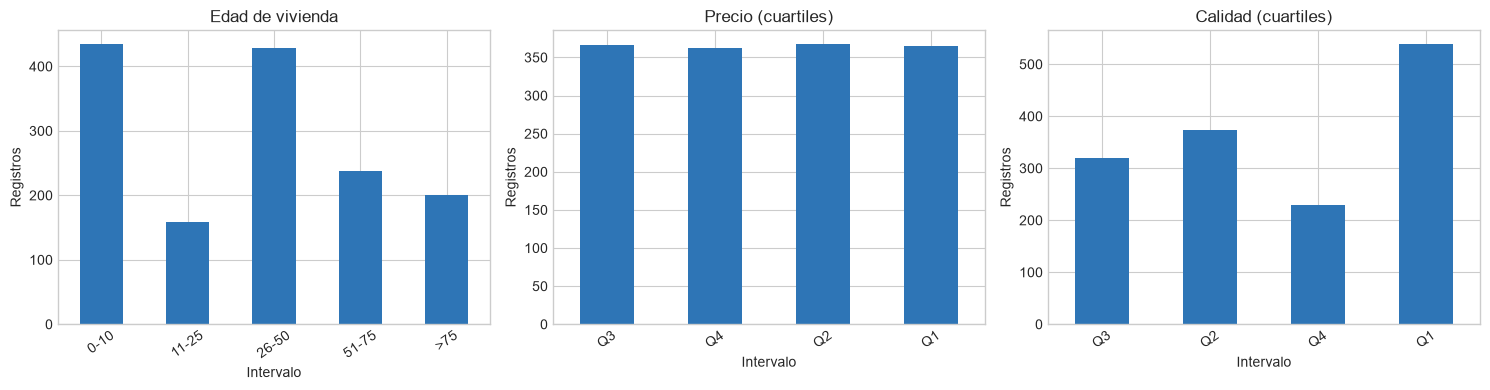

In [ ]:
df_discretized = df_text_corrected.copy(deep=True)
df_discretized["HouseAge_atSale"] = df_discretized["YrSold"] - df_discretized["YearBuilt"]
df_discretized["HouseAgeBin"] = pd.cut(
    df_discretized["HouseAge_atSale"],
    bins=[-1, 10, 25, 50, 75, np.inf],
    labels=["0-10", "11-25", "26-50", "51-75", ">75"],
    include_lowest=True,
)
price_codes = pd.qcut(df_discretized["SalePrice"], q=4, labels=False, duplicates="drop")
quality_codes = pd.qcut(df_discretized["OverallQual"], q=4, labels=False, duplicates="drop")
df_discretized["SalePriceBin"] = price_codes.map(lambda code: f"Q{int(code) + 1}")
df_discretized["OverallQualBin"] = quality_codes.map(lambda code: f"Q{int(code) + 1}")

bin_frames = []
for variable in ["HouseAgeBin", "SalePriceBin", "OverallQualBin"]:
    counts = df_discretized[variable].value_counts(sort=False, dropna=False)
    bin_frames.append(
        pd.DataFrame(
            {
                "variable": variable,
                "intervalo": counts.index.astype(str),
                "registros": counts.values,
                "porcentaje": counts.values / len(df_discretized) * 100,
            }
        )
    )
bin_summary = pd.concat(bin_frames, ignore_index=True)
display(bin_summary)
bin_summary.to_csv(TABLES_DIR / "distribucion_bins.csv", index=False)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for axis, column, title in zip(
    axes,
    ["HouseAgeBin", "SalePriceBin", "OverallQualBin"],
    ["Edad de vivienda", "Precio (cuartiles)", "Calidad (cuartiles)"],
):
    df_discretized[column].value_counts(sort=False).plot.bar(
        ax=axis, color=PLOT_COLORS["blue"]
    )
    axis.set_title(title)
    axis.set_xlabel("Intervalo")
    axis.set_ylabel("Registros")
    axis.tick_params(axis="x", rotation=35)
fig.tight_layout()
bins_figure = FIGURES_DIR / "distribucion_variables_discretizadas.png"
fig.savefig(bins_figure, dpi=160, bbox_inches="tight")
plt.show()

## 15. Feature Engineering orientado a `SalePrice`

Por último, se construyen seis variables nuevas combinando información que ya existía en el dataset: `HouseAge` (antigüedad al momento de la venta), `TotalSF` (superficie total sumando sótano y ambos pisos), `TotalBathrooms` (baños totales, ponderando los medios baños), `TotalPorchSF` (superficie total de porches), `HasGarage` (si la vivienda tiene garaje) y `Remodeled` (si fue remodelada después de construida). Para tener una primera idea de si estas variables se relacionan con el precio, se calcula la correlación de Spearman de cada una contra `SalePrice` y se visualizan con dispersogramas. Como siempre en este tipo de análisis, una correlación indica que dos variables se mueven juntas, no que una cause a la otra.

,spearman_con_SalePrice
TotalSF,0.819676
TotalBathrooms,0.703731
HouseAge,-0.650120
HasGarage,0.300454
TotalPorchSF,0.272704
Remodeled,-0.085533


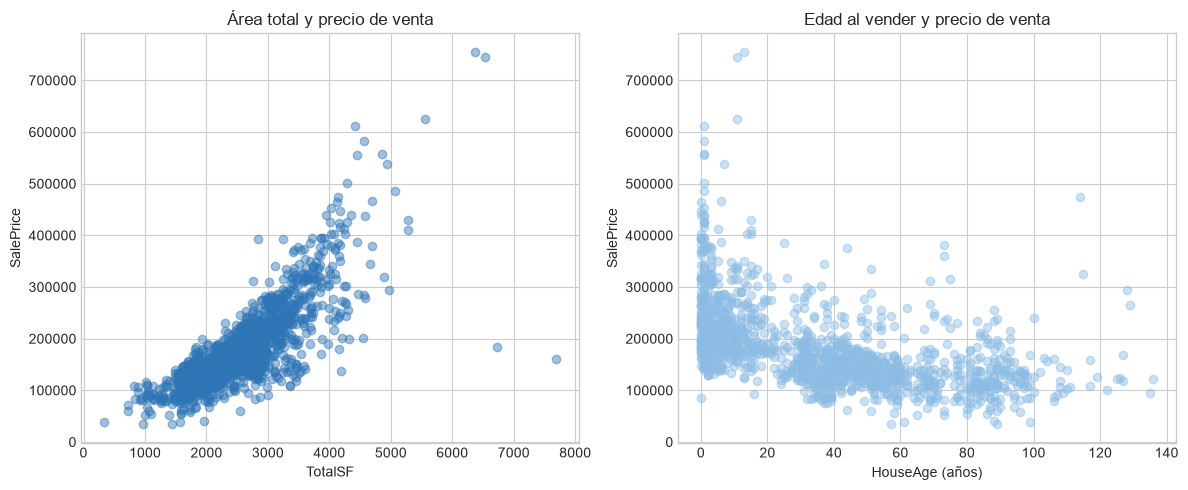

In [ ]:
df_engineered = df_discretized.copy(deep=True)
df_engineered["HouseAge"] = df_engineered["YrSold"] - df_engineered["YearBuilt"]
df_engineered["TotalSF"] = (
    df_engineered["TotalBsmtSF"]
    + df_engineered["1stFlrSF"]
    + df_engineered["2ndFlrSF"]
)
df_engineered["TotalBathrooms"] = (
    df_engineered["FullBath"]
    + 0.5 * df_engineered["HalfBath"]
    + df_engineered["BsmtFullBath"]
    + 0.5 * df_engineered["BsmtHalfBath"]
)
porch_columns = ["OpenPorchSF", "EnclosedPorch", "3SsnPorch", "ScreenPorch"]
df_engineered["TotalPorchSF"] = df_engineered[porch_columns].sum(axis=1)
df_engineered["HasGarage"] = (
    (df_engineered["GarageArea"] > 0) | (df_engineered["GarageCars"] > 0)
).astype("int8")
df_engineered["Remodeled"] = (
    df_engineered["YearRemodAdd"] > df_engineered["YearBuilt"]
).astype("int8")
df_engineered = df_engineered.drop(columns=["HouseAge_atSale"])

ENGINEERED_FEATURES = [
    "HouseAge", "TotalSF", "TotalBathrooms", "TotalPorchSF", "HasGarage", "Remodeled"
]
engineered_correlations = (
    df_engineered[ENGINEERED_FEATURES + ["SalePrice"]]
    .corr(method="spearman")["SalePrice"]
    .drop("SalePrice")
    .sort_values(key=abs, ascending=False)
    .rename("spearman_con_SalePrice")
    .to_frame()
)
display(engineered_correlations)
engineered_correlations.to_csv(TABLES_DIR / "correlacion_features_saleprice.csv")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(
    df_engineered["TotalSF"], df_engineered["SalePrice"],
    alpha=0.45, color=PLOT_COLORS["blue"],
)
axes[0].set_title("Área total y precio de venta")
axes[0].set_xlabel("TotalSF")
axes[0].set_ylabel("SalePrice")
axes[1].scatter(
    df_engineered["HouseAge"], df_engineered["SalePrice"],
    alpha=0.45, color=PLOT_COLORS["light_blue"],
)
axes[1].set_title("Edad al vender y precio de venta")
axes[1].set_xlabel("HouseAge (años)")
axes[1].set_ylabel("SalePrice")
fig.tight_layout()
feature_figure = FIGURES_DIR / "relacion_features_saleprice.png"
fig.savefig(feature_figure, dpi=160, bbox_inches="tight")
plt.show()